In [1]:
import braid_analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from braid_analysis import braid_filemanager
from braid_analysis import braid_2d_analysis as b2d

# Data folder

In [12]:
data_folder = '/Users/florisvb/src/braid_2d_3d_data/20260313_WT_motion_stim_split_node'
window_s    = 5.0   # seconds before/after each trigger to load and analyse

# Load experiment config and trigger events

In [13]:
exp_code    = b2d.load_exp_code(data_folder)
df_triggers = b2d.load_triggers(data_folder, exp_code)

print(f'Triggers loaded: {len(df_triggers)}')
print('Trigger counts per stimulus condition:')
print(df_triggers.groupby(exp_code['column_names']).size().reset_index(name='count').to_string(index=False))

Triggers loaded: 616
Trigger counts per stimulus condition:
 flash_duration  visual_motion_direction  visual_motion_speed  visual_motion_duration  count
            0.0                      0.0                  0.2                     5.0    334
            0.0                    180.0                  0.0                     5.0    282


# Load 3D data and the 2D data windowed around triggers

In [14]:
braidz_filename = b2d.get_filename(data_folder, '.braidz')

# Full 3D data (fast to load)
df_3d = braid_filemanager.load_filename_as_dataframe_3d(braidz_filename)
print('3D data shape:', df_3d.shape)

3D data shape: (6958477, 18)


# obj_ids present at each trigger frame

In [15]:
# Get trigger frame numbers from data_2 column and map to unique obj_ids in df_3d
trigger_frames = df_triggers['data_2'].dropna().astype(int).unique()

frame_to_obj_ids = {}
for frame in trigger_frames:
    obj_ids = df_3d.loc[df_3d['frame'] == frame, 'obj_id'].unique().tolist()
    frame_to_obj_ids[frame] = obj_ids

print(f'Trigger frames queried: {len(frame_to_obj_ids)}')
print(f'Example (first 5):')
for frame, ids in list(frame_to_obj_ids.items())[:5]:
    print(f'  frame {frame}: {ids}')

Trigger frames queried: 616
Example (first 5):
  frame 45612: [61]
  frame 47046: [64]
  frame 49285: [67]
  frame 51329: [67]
  frame 58977: [78]


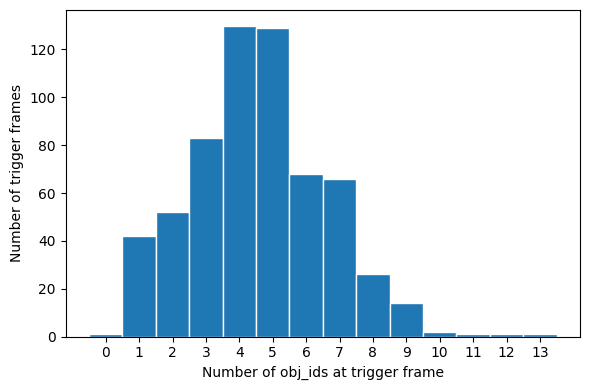

In [16]:
n_obj_ids = [len(ids) for ids in frame_to_obj_ids.values()]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(n_obj_ids, bins=range(max(n_obj_ids) + 2), align='left', edgecolor='white')
ax.set_xlabel('Number of obj_ids at trigger frame')
ax.set_ylabel('Number of trigger frames')
ax.set_xticks(range(max(n_obj_ids) + 1))
plt.tight_layout()
plt.show()

# Filter obj_ids by trigger logic from trigger_node.py

In [17]:
# Load the trigger checker from the experiment's trigger_node.py
# Returns a check(obj_id, frame) -> bool function and the parsed config
check_trigger, trigger_config = b2d.load_trigger_checker(data_folder, df_3d)

print('\nTrigger volume:')
for key in ['xmin', 'xmax', 'ymin', 'ymax', 'zmin', 'zmax']:
    print(f'  {key}: {trigger_config[key]}')

Trigger node: trigger_node.py
trigger_node.py config keys used in trigger_callback: ['min_trajec_length', 'refractory_time', 'vel_xmax', 'vel_xmin', 'vel_ymax', 'vel_ymin', 'vel_zmax', 'vel_zmin', 'xmax', 'xmin', 'ymax', 'ymin', 'zmax', 'zmin']
Config loaded: /Users/florisvb/src/braid_2d_3d_data/20260313_WT_motion_stim_split_node/exp_code/20260120_trigger_in_volume_vision_bar.yaml

Trigger volume:
  xmin: -0.3
  xmax: 0.3
  ymin: -0.1
  ymax: 0.1
  zmin: 0.1
  zmax: 0.4


In [18]:
# Build filtered dict: same structure as frame_to_obj_ids, but only obj_ids
# that pass the trigger_callback logic (birth time + position + velocity, no refractory)
frame_to_triggered_obj_ids = {}
for frame, obj_ids in frame_to_obj_ids.items():
    passed = [oid for oid in obj_ids if check_trigger(oid, frame)]
    if passed:
        frame_to_triggered_obj_ids[frame] = passed

n_frames_with_any   = len(frame_to_obj_ids)
n_frames_with_pass  = len(frame_to_triggered_obj_ids)
print(f'Frames with any obj_id:         {n_frames_with_any}')
print(f'Frames with a qualifying obj_id: {n_frames_with_pass}')

Frames with any obj_id:         616
Frames with a qualifying obj_id: 63


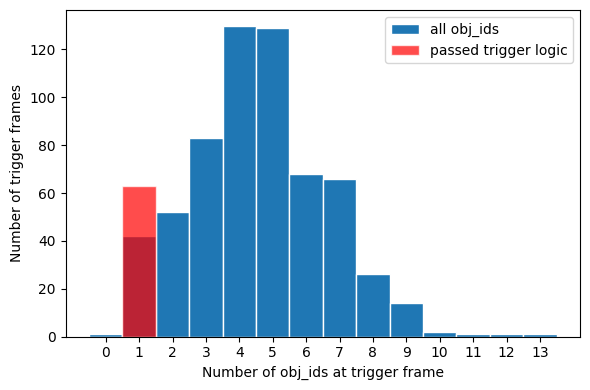

In [19]:
n_triggered_obj_ids = [len(ids) for ids in frame_to_triggered_obj_ids.values()]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(n_obj_ids, bins=range(max(n_obj_ids) + 2), align='left', edgecolor='white', label='all obj_ids')
ax.hist(n_triggered_obj_ids, bins=range(max(n_triggered_obj_ids) + 2), align='left',
        edgecolor='white', color='red', alpha=0.7, label='passed trigger logic')
ax.set_xlabel('Number of obj_ids at trigger frame')
ax.set_ylabel('Number of trigger frames')
ax.set_xticks(range(max(n_obj_ids) + 1))
ax.legend()
plt.tight_layout()
plt.show()

# Diagnosing the real-time vs post-hoc discrepancy

`data_1` = obj_id that triggered; `data_2` = frame number recorded at trigger time; `data_3` = wall-clock time of trigger.

We check:
1. Is the triggered obj_id even present in df_3d at the recorded frame?
2. Which condition fails most often (birth time, x, y, z, velocity)?
3. Does searching ±N frames around the trigger frame recover more passes?

In [80]:
# ── 1. Is the triggered obj_id present in df_3d at the recorded frame? ──────
# data_1 = triggered obj_id, data_2 = recorded frame number
df_indexed_frame = df_3d.set_index(['frame', 'obj_id'])
all_obj_ids_in_df3d = set(df_3d['obj_id'].unique())

results = []
for _, trig in df_triggers.iterrows():
    obj_id = int(trig['data_1'])
    frame  = int(trig['data_2'])
    present_at_frame  = (frame, obj_id) in df_indexed_frame.index
    present_anywhere  = obj_id in all_obj_ids_in_df3d
    results.append({'obj_id': obj_id, 'frame': frame,
                    'present_at_frame': present_at_frame,
                    'present_anywhere': present_anywhere})

df_diag = pd.DataFrame(results)
n_total           = len(df_diag)
n_at_frame        = df_diag['present_at_frame'].sum()
n_anywhere        = df_diag['present_anywhere'].sum()
n_not_anywhere    = n_total - n_anywhere

print(f'Total real-time triggers:                          {n_total}')
print(f'Triggered obj_id present in df_3d at exact frame: {n_at_frame}/{n_total} ({100*n_at_frame/n_total:.1f}%)')
print(f'Triggered obj_id present in df_3d at all:         {n_anywhere}/{n_total} ({100*n_anywhere/n_total:.1f}%)')
print(f'Triggered obj_id absent from df_3d entirely:      {n_not_anywhere}/{n_total} ({100*n_not_anywhere/n_total:.1f}%)')

Total real-time triggers:                          616
Triggered obj_id present in df_3d at exact frame: 452/616 (73.4%)
Triggered obj_id present in df_3d at all:         616/616 (100.0%)
Triggered obj_id absent from df_3d entirely:      0/616 (0.0%)


Nearest frame BEFORE trigger (offset ≤ 0):
  cases with a frame: 164/164
  mean=-2.6  median=-2.0  std=1.6  min=-11  max=-1

Nearest frame AFTER  trigger (offset ≥ 0):
  cases with a frame: 0/164



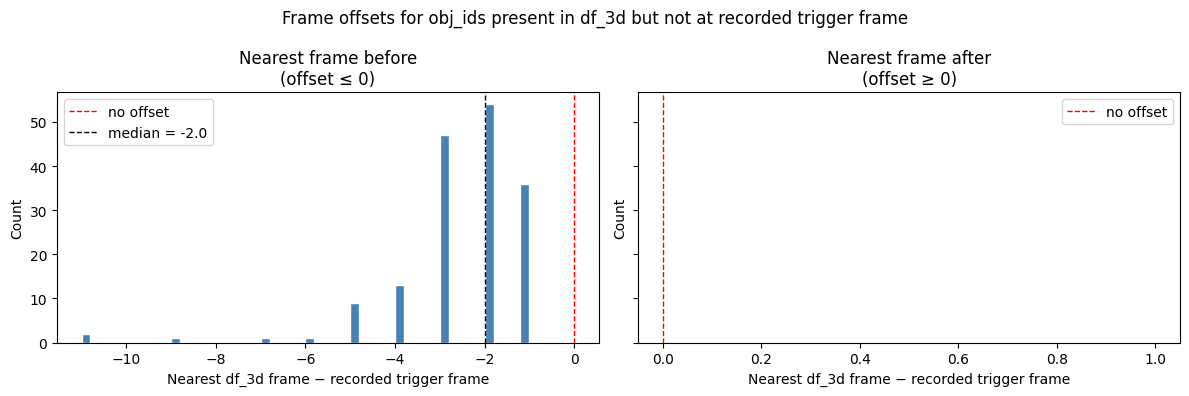

In [81]:
# For obj_ids present in df_3d but NOT at the recorded frame, find the nearest
# frame both before and after the recorded trigger frame independently.
# nearest_before: largest frame <= trigger_frame  (offset <= 0)
# nearest_after:  smallest frame >= trigger_frame  (offset >= 0)

obj_id_frames = df_3d.groupby('obj_id')['frame'].apply(np.array)

before_offsets = []  # nearest_before - trigger_frame  (always <= 0, or NaN if none)
after_offsets  = []  # nearest_after  - trigger_frame  (always >= 0, or NaN if none)

for _, row in df_diag[df_diag['present_anywhere'] & ~df_diag['present_at_frame']].iterrows():
    obj_id = row['obj_id']
    trigger_frame = row['frame']
    frames = obj_id_frames[obj_id]

    before = frames[frames < trigger_frame]
    after  = frames[frames > trigger_frame]

    before_offsets.append(before.max() - trigger_frame if len(before) else np.nan)
    after_offsets.append(after.min()  - trigger_frame if len(after)  else np.nan)

before_offsets = np.array(before_offsets)
after_offsets  = np.array(after_offsets)

for label, offsets in [('Nearest frame BEFORE trigger (offset ≤ 0)', before_offsets),
                        ('Nearest frame AFTER  trigger (offset ≥ 0)', after_offsets)]:
    valid = offsets[~np.isnan(offsets)]
    print(f'{label}:')
    print(f'  cases with a frame: {len(valid)}/{len(offsets)}')
    if len(valid):
        print(f'  mean={valid.mean():.1f}  median={np.median(valid):.1f}  '
              f'std={valid.std():.1f}  min={valid.min():.0f}  max={valid.max():.0f}')
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, offsets, label, color in [
        (axes[0], before_offsets, 'Nearest frame before\n(offset ≤ 0)', 'steelblue'),
        (axes[1], after_offsets,  'Nearest frame after\n(offset ≥ 0)',  'darkorange')]:
    valid = offsets[~np.isnan(offsets)]
    ax.hist(valid, bins=50, color=color, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1, label='no offset')
    if len(valid):
        ax.axvline(np.median(valid), color='black', linestyle='--', linewidth=1,
                   label=f'median = {np.median(valid):.1f}')
    ax.set_xlabel('Nearest df_3d frame − recorded trigger frame')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend()

plt.suptitle('Frame offsets for obj_ids present in df_3d but not at recorded trigger frame')
plt.tight_layout()
plt.show()

In [82]:
# ── 2. Condition breakdown: what fails for the triggered obj_id? ─────────────
birth_timestamps = df_3d.groupby('obj_id')['timestamp'].min()

conditions = ['not_in_df3d', 'birth_time', 'x_bounds', 'y_bounds', 'z_bounds', 'vel_x', 'vel_y', 'vel_z', 'passed']
counts = {c: 0 for c in conditions}

for _, trig in df_triggers.iterrows():
    obj_id = int(trig['data_1'])
    frame  = int(trig['data_2'])

    try:
        row = df_indexed_frame.loc[(frame, obj_id)]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
    except KeyError:
        counts['not_in_df3d'] += 1
        continue

    age = row['timestamp'] - birth_timestamps.get(obj_id, row['timestamp'])
    if age < trigger_config.get('min_trajec_length', 0):
        counts['birth_time'] += 1; continue
    if not (trigger_config['xmin'] < row['x'] < trigger_config['xmax']):
        counts['x_bounds'] += 1; continue
    if not (trigger_config['ymin'] < row['y'] < trigger_config['ymax']):
        counts['y_bounds'] += 1; continue
    if not (trigger_config['zmin'] < row['z'] < trigger_config['zmax']):
        counts['z_bounds'] += 1; continue
    if not (trigger_config['vel_xmin'] < row['xvel'] < trigger_config['vel_xmax']):
        counts['vel_x'] += 1; continue
    if not (trigger_config['vel_ymin'] < row['yvel'] < trigger_config['vel_ymax']):
        counts['vel_y'] += 1; continue
    if not (trigger_config['vel_zmin'] < row['zvel'] < trigger_config['vel_zmax']):
        counts['vel_z'] += 1; continue
    counts['passed'] += 1

print('Condition breakdown for triggered obj_ids at their recorded frame:')
for k, v in counts.items():
    print(f'  {k:20s}: {v:4d}  ({100*v/n_total:.1f}%)')

Condition breakdown for triggered obj_ids at their recorded frame:
  not_in_df3d         :  164  (26.6%)
  birth_time          :  389  (63.1%)
  x_bounds            :    0  (0.0%)
  y_bounds            :    0  (0.0%)
  z_bounds            :    0  (0.0%)
  vel_x               :    0  (0.0%)
  vel_y               :    0  (0.0%)
  vel_z               :    0  (0.0%)
  passed              :   63  (10.2%)


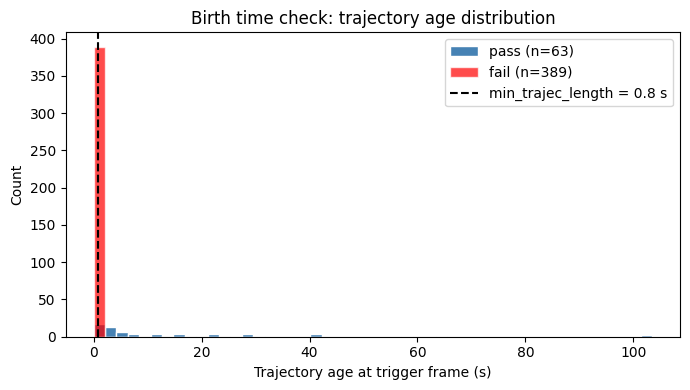

In [83]:
# Histogram of trajectory ages at the trigger frame for obj_ids that fail the birth time check
min_trajec_length = trigger_config.get('min_trajec_length', 0)

ages_fail = []
ages_pass = []
for _, trig in df_triggers.iterrows():
    obj_id = int(trig['data_1'])
    frame  = int(trig['data_2'])
    try:
        row = df_indexed_frame.loc[(frame, obj_id)]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
    except KeyError:
        continue
    age = row['timestamp'] - birth_timestamps.get(obj_id, row['timestamp'])
    (ages_fail if age < min_trajec_length else ages_pass).append(age)

fig, ax = plt.subplots(figsize=(7, 4))
all_ages = ages_fail + ages_pass
bins = np.linspace(0, max(all_ages), 50)
ax.hist(ages_pass, bins=bins, label=f'pass (n={len(ages_pass)})', color='steelblue', edgecolor='white')
ax.hist(ages_fail, bins=bins, label=f'fail (n={len(ages_fail)})', color='red', alpha=0.7, edgecolor='white')
ax.axvline(min_trajec_length, color='black', linestyle='--', linewidth=1.5,
           label=f'min_trajec_length = {min_trajec_length} s')
ax.set_xlabel('Trajectory age at trigger frame (s)')
ax.set_ylabel('Count')
ax.set_title('Birth time check: trajectory age distribution')
ax.legend()
plt.tight_layout()
plt.show()

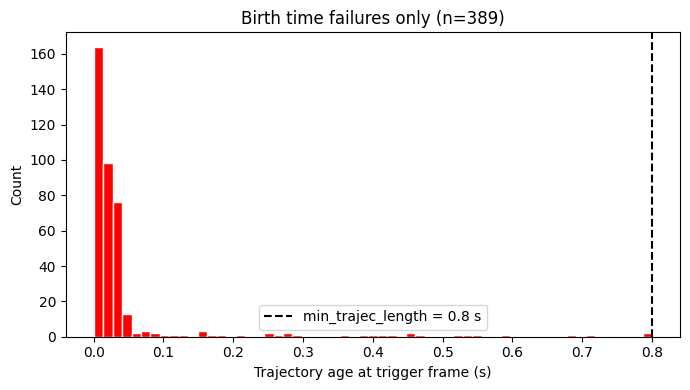

In [84]:
# Zoomed-in histogram of ages for failed trajectories only
fig, ax = plt.subplots(figsize=(7, 4))
bins_fail = np.linspace(0, min_trajec_length, 60)
ax.hist(ages_fail, bins=bins_fail, color='red', edgecolor='white')
ax.axvline(min_trajec_length, color='black', linestyle='--', linewidth=1.5,
           label=f'min_trajec_length = {min_trajec_length} s')
ax.set_xlabel('Trajectory age at trigger frame (s)')
ax.set_ylabel('Count')
ax.set_title(f'Birth time failures only (n={len(ages_fail)})')
ax.legend()
plt.tight_layout()
plt.show()

Birth-time failures: 389

Age at trigger FRAME  (post-hoc, row timestamp - birth):
  mean=0.047  median=0.020  max=0.800 s

Age at trigger SEND TIME (data_3 - birth):
  mean=0.080  median=0.049  max=0.824 s


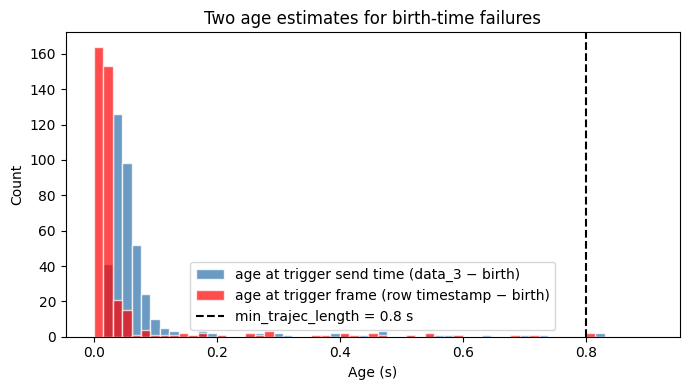

In [85]:
# For obj_ids that fail the post-hoc birth time check, compare two age estimates:
#   age_at_frame : row['timestamp'] - birth_timestamps[obj_id]  (what post-hoc computes)
#   age_at_trigger: data_3 - birth_timestamps[obj_id]           (trigger send time minus df_3d birth)
#
# If age_at_trigger >> 0.8s but age_at_frame < 0.8s, the trigger frame timestamp
# is anomalously early — suggesting the recorded frame (data_2) doesn't actually
# correspond to when the trigger fired.

ages_at_frame   = []  # post-hoc age: timestamp at trigger frame - birth timestamp
ages_at_trigger = []  # age using trigger send time: data_3 - birth timestamp

for _, trig in df_triggers.iterrows():
    obj_id = int(trig['data_1'])
    frame  = int(trig['data_2'])
    t_ros  = trig['data_3']
    try:
        row = df_indexed_frame.loc[(frame, obj_id)]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
    except KeyError:
        continue
    age_frame   = row['timestamp'] - birth_timestamps.get(obj_id, row['timestamp'])
    age_trigger = t_ros - birth_timestamps.get(obj_id, t_ros)
    if age_frame < min_trajec_length:  # only look at failures
        ages_at_frame.append(age_frame)
        ages_at_trigger.append(age_trigger)

ages_at_frame   = np.array(ages_at_frame)
ages_at_trigger = np.array(ages_at_trigger)

print(f'Birth-time failures: {len(ages_at_frame)}')
print(f'\nAge at trigger FRAME  (post-hoc, row timestamp - birth):')
print(f'  mean={ages_at_frame.mean():.3f}  median={np.median(ages_at_frame):.3f}  max={ages_at_frame.max():.3f} s')
print(f'\nAge at trigger SEND TIME (data_3 - birth):')
print(f'  mean={ages_at_trigger.mean():.3f}  median={np.median(ages_at_trigger):.3f}  max={ages_at_trigger.max():.3f} s')

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, max(ages_at_trigger.max(), min_trajec_length) * 1.1, 60)
ax.hist(ages_at_trigger, bins=bins, color='steelblue', alpha=0.8, edgecolor='white',
        label='age at trigger send time (data_3 − birth)')
ax.hist(ages_at_frame, bins=bins, color='red', alpha=0.7, edgecolor='white',
        label='age at trigger frame (row timestamp − birth)')
ax.axvline(min_trajec_length, color='black', linestyle='--', linewidth=1.5,
           label=f'min_trajec_length = {min_trajec_length} s')
ax.set_xlabel('Age (s)')
ax.set_ylabel('Count')
ax.set_title('Two age estimates for birth-time failures')
ax.legend()
plt.tight_layout()
plt.show()

df_3d timestamp − ROS trigger time (data_3):
  mean:   -0.0335 s
  median: -0.0267 s
  std:    0.0149 s
  min:    -0.1117 s
  max:    -0.0166 s


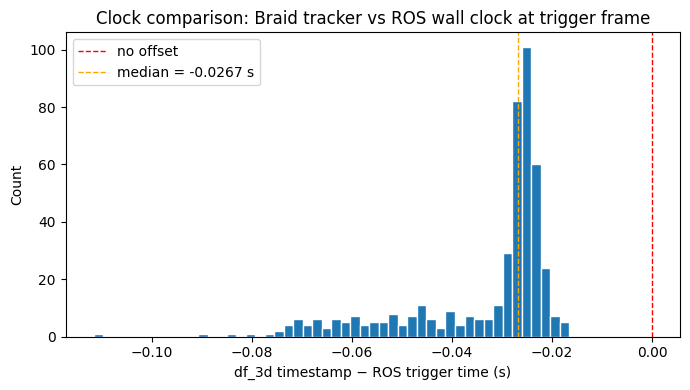

In [86]:
# Compare data_3 (ROS wall-clock time the trigger was sent) with the df_3d timestamp
# at the recorded trigger frame. A large or systematic offset means the two clocks
# are in different time bases, which would corrupt the post-hoc birth time calculation.

time_diffs = []  # df_3d timestamp - data_3 (ROS trigger time)
for _, trig in df_triggers.iterrows():
    obj_id = int(trig['data_1'])
    frame  = int(trig['data_2'])
    t_ros  = trig['data_3']
    try:
        row = df_indexed_frame.loc[(frame, obj_id)]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
    except KeyError:
        continue
    time_diffs.append(row['timestamp'] - t_ros)

time_diffs = np.array(time_diffs)
print(f'df_3d timestamp − ROS trigger time (data_3):')
print(f'  mean:   {time_diffs.mean():.4f} s')
print(f'  median: {np.median(time_diffs):.4f} s')
print(f'  std:    {time_diffs.std():.4f} s')
print(f'  min:    {time_diffs.min():.4f} s')
print(f'  max:    {time_diffs.max():.4f} s')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(time_diffs, bins=50, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='no offset')
ax.axvline(np.median(time_diffs), color='orange', linestyle='--', linewidth=1,
           label=f'median = {np.median(time_diffs):.4f} s')
ax.set_xlabel('df_3d timestamp − ROS trigger time (s)')
ax.set_ylabel('Count')
ax.set_title('Clock comparison: Braid tracker vs ROS wall clock at trigger frame')
ax.legend()
plt.tight_layout()
plt.show()

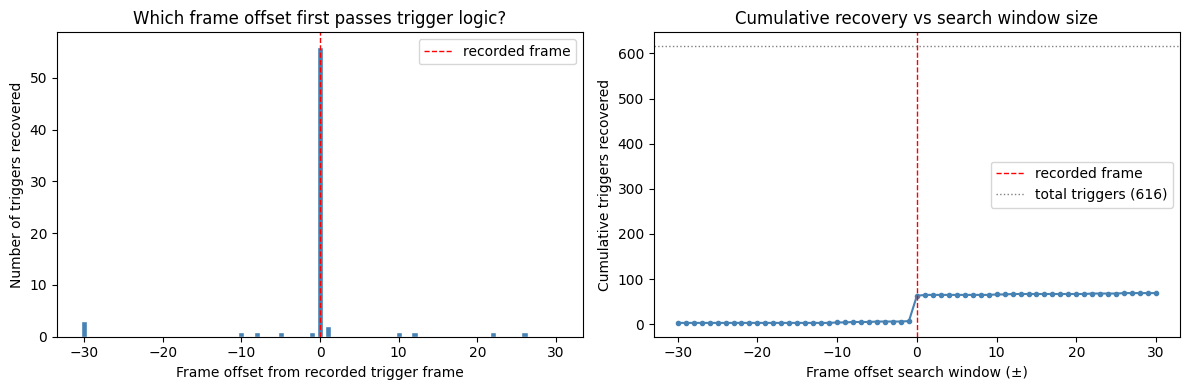

At offset 0 (exact frame): 56/616 pass
Within ±30 frames:  69/616 pass


In [87]:
# ── 3. Does searching ±N frames around the trigger frame recover passes? ──────
# If yes, the frame number in data_2 is systematically offset from when the
# fly was actually in the volume (latency / packet-ordering bug).
search_half_window = 30  # frames to search either side

df_3d_obj_frame = df_3d.set_index('obj_id')  # index by obj_id for fast trajectory lookup

recovered = {offset: 0 for offset in range(-search_half_window, search_half_window + 1)}

for _, trig in df_triggers.iterrows():
    obj_id = int(trig['data_1'])
    frame  = int(trig['data_2'])

    traj = df_3d[df_3d['obj_id'] == obj_id].set_index('frame')

    for offset in range(-search_half_window, search_half_window + 1):
        f = frame + offset
        if f not in traj.index:
            continue
        row = traj.loc[f]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        age = row['timestamp'] - birth_timestamps.get(obj_id, row['timestamp'])
        if age < trigger_config.get('min_trajec_length', 0):
            continue
        if not (trigger_config['xmin'] < row['x'] < trigger_config['xmax']):
            continue
        if not (trigger_config['ymin'] < row['y'] < trigger_config['ymax']):
            continue
        if not (trigger_config['zmin'] < row['z'] < trigger_config['zmax']):
            continue
        recovered[offset] += 1
        break  # count this trigger as recovered at earliest passing offset

offsets = list(recovered.keys())
counts_by_offset = [recovered[o] for o in offsets]
cumulative = np.cumsum([recovered[o] for o in sorted(offsets)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(offsets, counts_by_offset, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='recorded frame')
axes[0].set_xlabel('Frame offset from recorded trigger frame')
axes[0].set_ylabel('Number of triggers recovered')
axes[0].set_title('Which frame offset first passes trigger logic?')
axes[0].legend()

axes[1].plot(sorted(offsets), cumulative, color='steelblue', marker='o', markersize=3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, label='recorded frame')
axes[1].axhline(n_total, color='grey', linestyle=':', linewidth=1, label=f'total triggers ({n_total})')
axes[1].set_xlabel('Frame offset search window (±)')
axes[1].set_ylabel('Cumulative triggers recovered')
axes[1].set_title('Cumulative recovery vs search window size')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'At offset 0 (exact frame): {recovered[0]}/{n_total} pass')
print(f'Within ±{search_half_window} frames:  {sum(counts_by_offset)}/{n_total} pass')